In [2]:
# Importing required modules and libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

import requests

## Task 1: Importing the dataset
**Download the dataset** and perform simple **data cleaning** step

In [4]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
    else:
        print('Download failed: ', response.status_code)

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
filename = 'insurance.csv'
download(url, filename)

df = pd.read_csv(filename)
df.head()

,19,1,27.9,0,1.1,3,16884.924
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160


In [5]:
# Adding headers to the columns
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers

# Replacing the ? with NaN
df.replace("?", np.nan, inplace=True)

df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,NaN,4,3756.62160


## Task 2: Data wrangling

Handle missing data:

For **continuous attributes** (e.g., age), replace missing values with the **mean**.<br>
For **categorical attributes** (e.g., smoker), replace missing values with the **mode**.

Update the **data types** of the respective columns.<br>
Verify the update using **df.info()**.

In [7]:
# smoker is a categorical attribute --> replace with the most frequent value 
is_smoker = df['smoker'].value_counts().idxmax()
df['smoker'].replace(np.nan, is_smoker, inplace=True)

# age is a numerical value --> replace with the mean value
mean_age = df['age'].astype('float').mean(axis=0)
df['age'].replace(np.nan, mean_age, inplace=True)

# Update data types
df[["age","smoker"]] = df[["age","smoker"]].astype("int")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2771 non-null   int32  
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2771 non-null   int32  
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int32(2), int64(3)
memory usage: 130.0 KB
None


Also note, that the charges column has values which are **more than 2 decimal places** long. <br>
Update the charges column such that all values are rounded to nearest 2 decimal places. <br>
Verify conversion by printing the first 5 values of the updated dataframe.

In [ ]:
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())

## Task 3 : Exploratory Data Analysis (EDA)

Implement the **regression plot** for **charges** with respect to **bmi**.

(0.0, 66902.8557155)

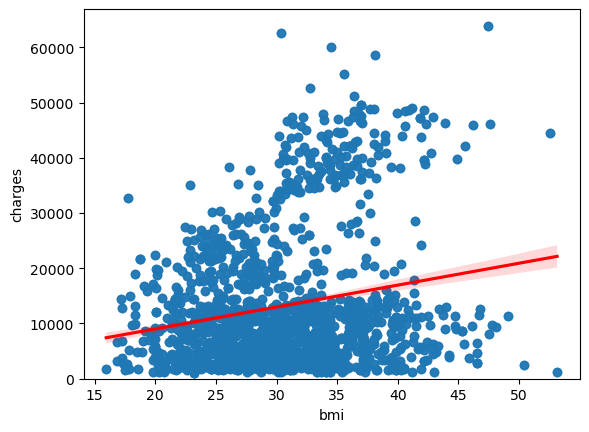

In [8]:
sns.regplot(x='bmi', y='charges', data=df, line_kws={'color': 'red'})
plt.ylim(0,)

Implement the **box plot** for **charges** with respect to **smoker**.

<Axes: xlabel='smoker', ylabel='charges'>

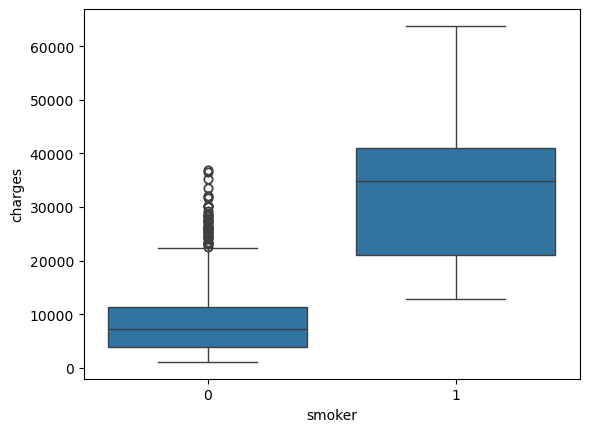

In [9]:
sns.boxplot(x='smoker', y='charges', data=df)

Print the **correlation matrix** for the dataset.

In [10]:
print(df.corr())

                     age    gender       bmi  no_of_children    smoker  \
age             1.000000 -0.026584  0.112859        0.037126 -0.022290   
gender         -0.026584  1.000000  0.042766        0.015693  0.083125   
bmi             0.112859  0.042766  1.000000       -0.001642  0.011824   
no_of_children  0.037126  0.015693 -0.001642        1.000000  0.007016   
smoker         -0.022290  0.083125  0.011824        0.007016  1.000000   
region         -0.006969  0.022360  0.271200       -0.025594  0.053839   
charges         0.298892  0.062959  0.199906        0.066551  0.789141   

                  region   charges  
age            -0.006969  0.298892  
gender          0.022360  0.062959  
bmi             0.271200  0.199906  
no_of_children -0.025594  0.066551  
smoker          0.053839  0.789141  
region          1.000000  0.054018  
charges         0.054018  1.000000  


## Task 4 : Model Development

Fit a **linear regression** model to predict the **charges** value, just by using the **smoker** attribute of the dataset. <br> Print the **R^2 score** of this model.

In [11]:
lr1 = LinearRegression()
x = df[['smoker']]
y = df['charges']

lr1.fit(x, y)

print(lr1.score(x, y))

0.6227430384081845


Fit a **linear regression** model that to predict the **charges** value, just by using **all other attributes** of the dataset. <br>
Print the **R^2 score** of this model. You should see an improvement in the performance.

In [12]:
lr2 = LinearRegression()
x = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
y = df['charges']

lr2.fit(x, y)

print(lr2.score(x, y))

0.7505888658724134


Create a training pipeline that uses **StandardScaler(), PolynomialFeatures() and LinearRegression()** to create a model that can predict the charges value using all the other attributes of the dataset. <br>There should be even further improvement in the performance.

In [14]:
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), 
         ('model', LinearRegression())]
pipe = Pipeline(Input)
x = x.astype(float)
pipe.fit(x,y)
ypipe=pipe.predict(x)
print(r2_score(y,ypipe))

0.8453651702478724


## Task 5 : Model Refinement

Split the data into **training and testing** subsets, assuming that **20% of the data** will be reserved for testing.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

Initialize a Ridge regressor that used hyperparameter **alpha = 0.1** <br>
Fit the model using training data data subset. <br>
Print the **R^2 score** for the testing data.

In [16]:
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.7254198907320979


Apply polynomial transformation to the training parameters with **degree=2**. <br> Use this transformed feature set to fit the **same regression model**, as above, using the training subset. <br> Print the R^2 score for the testing subset.

In [17]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.8208413223345635
